<a href="https://colab.research.google.com/github/angelms2003/FernandezMartinezPolo-EML-RL/blob/main/Entornos_Complejos/SARSA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SARSA

*Description*: En este notebook se desarrolla la implementación del método de **SARSA**, y se emplea sobre el entorno Taxi-v3 de Gymnasium.


    Autores: David Fernández Expósito
             Ángel Martínez Sánchez
             Javier Polo Gambín

    Emails: dfernandezexposito@um.es
            angel.martinezs@um.es
            javier.polog@um.es
            
    Date: 2026/02/25

Empezamos instalando e importando las librerías necesarias. También definimos los dispositivos donde se ejecutará el notebook y la semilla que vamos a usar para asegurar reproducibilidad.

In [1]:
%%capture
!pip install 'gym[box2d]==0.20.0'

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym
import torch
import gc
import os

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

SEED = 42

# NumPy
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

# Python
os.environ["PYTHONHASHSEED"] = str(SEED)

Usando dispositivo: cpu


## Agente

Para implementar los distintos métodos de aprendizaje estudiados en la asignatura, hemos seguido las recomendaciones de Gymnasium para la creación de agentes y la generación de episodios, tal como se indicaba en la definición de la práctica. La idea central ha sido encapsular toda la lógica de interacción y aprendizaje en una clase `Agente`, adaptable a los diferentes algoritmos que se desean evaluar.

En este trabajo nos centramos en **SARSA**, un método de **Diferencias Temporales (TD)** de tipo **On-Policy**. A diferencia de los métodos Monte Carlo, que deben esperar al final de un episodio completo para actualizar los valores $Q(S,A)$, SARSA realiza actualizaciones **paso a paso** (*bootstrapping*), lo que le permite aprender de manera incremental a partir de cada transición individual.

El nombre del algoritmo proviene de la quíntupla de eventos que utiliza en cada actualización: $(S_t, A_t, R_{t+1}, S_{t+1}, A_{t+1})$. La regla de actualización es:

$$
Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \left[ R_{t+1} + \gamma \, Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t) \right]
$$

donde $\alpha$ es la tasa de aprendizaje y $\gamma$ es el factor de descuento. Al ser un método On-Policy, SARSA evalúa y mejora la misma política que utiliza para tomar decisiones. Esto implica que la acción $A_{t+1}$ del siguiente estado se elige siguiendo la política actual (típicamente $\epsilon$-greedy), y es esa misma acción la que se usa para calcular el *TD target*.

En cuanto a la exploración, el agente utiliza una política **$\epsilon$-greedy** que combina explotación de la acción con mayor valor esperado con exploración aleatoria. Además, se implementa un mecanismo de **decaimiento de $\epsilon$** (*epsilon decay*), que reduce progresivamente la probabilidad de exploración a lo largo del entrenamiento. Esto permite una fase inicial de exploración intensa seguida de una consolidación progresiva hacia políticas más explotadoras.

La principal ventaja de SARSA frente a Monte Carlo radica en la eficiencia de sus actualizaciones: al corregir los valores $Q$ tras cada acción (y no al final del episodio), el agente puede penalizar trayectorias ineficientes de forma inmediata, lo que resulta especialmente beneficioso en entornos con episodios largos como Taxi-v3.

In [4]:
class SARSAAgent:

    def __init__(self, env: gym.Env, epsilon: float, use_decay: bool, alpha: float, gamma: float,
                 epsilon_decay: float = 0.990, epsilon_min: float = 0.01):
        self.env = env
        self.eps = epsilon
        self.use_decay = use_decay
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min

        self.n_states = env.observation_space.n
        self.n_actions = env.action_space.n
        self.q_table = np.zeros((self.n_states, self.n_actions))

    def get_q_values(self):
        return self.q_table

    # Política epsilon-greedy para el entrenamiento
    def epsilon_greedy_policy(self, state):
        """Selecciona una acción usando política epsilon-greedy."""
        if np.random.random() < self.eps:
            return self.env.action_space.sample()
        else:
            return np.argmax(self.q_table[state, :])

    # Política Greedy para evaluar la política final obtenida
    def greedy_action(self, state):
        """Selecciona la mejor acción según la tabla Q (explotación pura)."""
        return np.argmax(self.q_table[state, :])

    # Función de actualización paso a paso
    def update(self, state, action, reward, next_state, next_action, done):
        """
        Actualización On-Policy (SARSA).
        A diferencia de Q-Learning, usamos el Q-valor de la acción que REALMENTE
        vamos a tomar (next_action), no el máximo.
        """
        current_q = self.q_table[state, action]
        next_q = self.q_table[next_state, next_action] if not done else 0.0
        self.q_table[state, action] = current_q + self.alpha * (reward + self.gamma * next_q - current_q)

## Esquema de aprendizaje

Ahora implementamos el proceso de aprendizaje. La función `train_sarsa` ejecuta el bucle de entrenamiento de SARSA durante un número determinado de episodios.

A diferencia del esquema de Monte Carlo, donde la actualización se realizaba al final de cada episodio completo, aquí la actualización se realiza en cada paso de la interacción con el entorno. Esto constituye la diferencia fundamental entre ambas familias de métodos.

El flujo de SARSA es el siguiente: antes de entrar al bucle interno del episodio, se elige la primera acción $A_0$ según la política $\epsilon$-greedy. Dentro del bucle, se ejecuta la acción, se observa la transición $(S_t, A_t, R_{t+1}, S_{t+1})$, se elige la siguiente acción $A_{t+1}$ (también según la política actual), y se actualiza $Q(S_t, A_t)$. Al finalizar cada episodio se aplica el decaimiento de $\epsilon$ y se registran las métricas de recompensa acumulada media y longitud del episodio.

In [5]:
def train_sarsa(agente, num_episodes=5000):

    # Para mostrar la evolución y métricas
    stats = 0.0
    list_stats = []
    step_display = num_episodes / 10

    longitudes = []

    for t in tqdm(range(num_episodes)):
        state, info = agente.env.reset(seed=SEED)

        # Aplicamos epsilon decay multiplicativo si está habilitado
        if agente.use_decay:
            agente.eps = max(agente.epsilon_min, agente.eps * agente.epsilon_decay)

        # SARSA: Elegimos la primera acción ANTES de entrar al bucle
        action = agente.epsilon_greedy_policy(state)

        done = False
        result_sum = 0.0
        steps = 0

        while not done:
            # Ejecutamos la acción
            next_state, reward, terminated, truncated, info = agente.env.step(action)
            done = terminated or truncated

            # Elegimos la siguiente acción basándonos en la política actual
            next_action = agente.epsilon_greedy_policy(next_state)

            # Actualizamos Q(S, A) paso a paso
            agente.update(state, action, reward, next_state, next_action, done)

            # Avanzamos el estado y la acción
            state = next_state
            action = next_action

            result_sum += reward
            steps += 1

        stats += result_sum
        longitudes.append(steps)
        list_stats.append(stats / (t + 1))

        if t % step_display == 0 and t != 0:
            print(f"success: {stats/t}, epsilon: {agente.eps}")

    return longitudes, list_stats

## Funciones auxiliares

Ahora vamos a definir una serie de funciones auxiliares que nos van a servir para mostrar resultados y realizar el análisis.

In [6]:
def capture_optimal_behavior(agente, limit_steps=100):
    """
    Graba un episodio completo siguiendo la política óptima del agente
    y devuelve las métricas de rendimiento junto con los frames de video.
    """
    visual_frames = []
    current_state, _ = agente.env.reset(seed=SEED)

    accumulated_reward = 0.0
    steps_count = 0
    is_finished = False

    while not is_finished and steps_count < limit_steps:
        img_frame = agente.env.render()
        visual_frames.append(img_frame)

        chosen_action = np.argmax(agente.get_q_values()[current_state, :])

        next_s, reward, terminated, truncated, _ = agente.env.step(chosen_action)

        accumulated_reward += reward
        current_state = next_s
        steps_count += 1
        is_finished = terminated or truncated

    visual_frames.append(agente.env.render())
    agente.env.close()

    return accumulated_reward, steps_count, visual_frames

Las siguiente funciones mostrarán las gráficas de aprendizaje y longitud de los episodios una vez realizado el aprendizaje de los agentes.

La longitud del episodio es un medidor de rendimiento interesante porque no solo indica si el agente alcanza la meta, sino también cómo de eficiente es la política aprendida.

En entornos donde existe una ruta óptima, la convergencia hacia un número estable y bajo de pasos suele reflejar que el agente ha aprendido un comportamiento estructurado y cercano al óptimo.

In [7]:
def draw_multiple_learning_curves(results_dict, limit=None):
    """
    Representa varias curvas de entrenamiento en el mismo gráfico.
    """

    first_key = next(iter(results_dict))
    x_axis = np.arange(len(results_dict[first_key]))

    fig, ax = plt.subplots(figsize=(10, 4))

    for experiment_name, history in results_dict.items():
        ax.plot(x_axis, history, label=experiment_name)

    if limit:
        ax.set_xlim(0, limit)
        ax.set_title(f"Comparativa de rendimiento — SARSA (primeros {limit} episodios)")
    else:
        ax.set_title("Comparativa de rendimiento (SARSA)")

    ax.set_xlabel("Número de episodio")
    ax.set_ylabel("Valor medio")
    ax.legend()

    ax.grid()
    plt.show()


def compute_running_mean(series, window):
    """Calcula un suavizado tipo media deslizante sobre una serie temporal."""
    kernel = np.full(window, 1.0 / window)
    return np.convolve(series, kernel, mode="valid")


def draw_episode_length_trend(length_history, limit=None):
    """
    Visualiza la evolución del tamaño de los episodios junto con
    una versión suavizada para observar la tendencia global.
    """

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(length_history, alpha=0.25, color="forestgreen")

    smoothing_window = 100
    smoothed = compute_running_mean(length_history, smoothing_window)

    ax.plot(
        np.arange(len(smoothed)),
        smoothed,
        linewidth=2,
        color="darkgreen",
        label="Media suavizada"
    )

    if limit:
        ax.set_xlim(0, limit)
        ax.set_title(f"Evolución del tamaño de episodio — SARSA (primeros {limit} episodios)")
    else:
        ax.set_title("Evolución del tamaño de episodio (SARSA)")

    ax.set_xlabel("Índice de episodio")
    ax.set_ylabel("Número de pasos")
    ax.legend()
    ax.grid()

    plt.show()


def draw_episode_length_comparison(length_dict, limit=None):
    """
    Compara la evolución de longitud de episodio entre varios experimentos.
    """

    palette = ["darkred", "navy", "darkgreen", "purple", "orange", "lightblue"]

    fig, ax = plt.subplots(figsize=(10, 4))

    smoothing_window = 100

    for idx, (label, values) in enumerate(length_dict.items()):

        color = palette[idx % len(palette)]

        ax.plot(values, alpha=0.2, color=color)

        smoothed = compute_running_mean(values, smoothing_window)
        ax.plot(
            np.arange(len(smoothed)),
            smoothed,
            linewidth=2,
            color=color,
            label=label
        )

    if limit:
        ax.set_xlim(0, limit)
        ax.set_title(f"Comparativa de longitudes de episodio — SARSA (primeros {limit} episodios)")
    else:
        ax.set_title("Comparativa de longitudes de episodio (SARSA)")

    ax.set_xlabel("Índice de episodio")
    ax.set_ylabel("Número de pasos")
    ax.legend()
    ax.grid()

    plt.show()

Las siguientes funciones servirán para visualizar los resultados con imágenes y gifs del comportamiento del agente.

In [8]:
import seaborn as sns
import imageio
import base64
from IPython.display import HTML
import matplotlib.pyplot as plt

def get_taxi_qtable_directions(qtable, env):
    """
    Extrae la matriz de valores Q máximos y los símbolos de las mejores acciones
    para una configuración específica del pasajero y destino en Taxi-v3.
    """
    state, _ = env.reset(seed=SEED)
    _, _, pass_idx, dest_idx = env.unwrapped.decode(state)
    q_max_grid = np.zeros((5, 5))
    directions_grid = np.empty((5, 5), dtype=object)

    # Mapeo de acciones para Taxi-v3
    # 0: Sur, 1: Norte, 2: Este, 3: Oeste, 4: Recoger (P), 5: Dejar (D)
    action_symbols = {0: '↓', 1: '↑', 2: '→', 3: '←', 4: 'P', 5: 'D'}

    for row in range(5):
        for col in range(5):
            state = env.unwrapped.encode(row, col, pass_idx, dest_idx)
            best_action = int(np.argmax(qtable[state]))
            max_q_value = np.max(qtable[state])

            q_max_grid[row, col] = max_q_value
            directions_grid[row, col] = action_symbols[best_action]

    return q_max_grid, directions_grid


def plot_taxi_q_values_map(qtable, env):
    '''
    Plotea un mapa de calor (Heatmap) de la política aprendida y los valores Q máximos.
    '''
    q_max_grid, directions_grid = get_taxi_qtable_directions(qtable, env)

    plt.figure(figsize=(7, 6))
    ax = sns.heatmap(
        q_max_grid,
        annot=directions_grid,
        fmt="",
        cmap=sns.color_palette("Blues", as_cmap=True),
        linewidths=1.5,
        linecolor="black",
        xticklabels=[],
        yticklabels=[],
        cbar_kws={'label': 'Max Q-Value estimado'},
        annot_kws={"fontsize": 18, "weight": "bold", "color": "black"},
    )
    ax.set_title("Learned Q-values\nArrows and letters (P/D) represent best action", fontsize=14)

    for _, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_linewidth(1.5)
        spine.set_color("black")

    plt.tight_layout()
    plt.show()


def create_gif_from_frames(frame_list, output_path="agent_taxi.gif"):
    """Genera un GIF animado a partir de una lista de imágenes."""
    with imageio.get_writer(output_path, mode="I") as gif_writer:
        for frame in frame_list:
            gif_writer.append_data(frame)
    return output_path


def show_gif_in_notebook(gif_file_path):
    """Inserta un GIF en una celda de Jupyter Notebook o Colab."""
    with open(gif_file_path, "rb") as f:
        gif_bytes = f.read()
    b64_str = base64.b64encode(gif_bytes).decode("utf-8")
    return HTML(f'<img src="data:image/gif;base64,{b64_str}" />')

## Entorno Taxi-v3

A continuación, creamos el entorno "Taxi-v3" de Gymnasium con el que trabajaremos. Es el mismo que se utilizó en el notebook de Monte Carlo. Recordamos las características principales del mismo:

* **Estados (500):** Combina 25 posiciones del taxi (cuadrícula 5x5), 5 posiciones posibles del pasajero (4 ubicaciones + dentro del taxi) y 4 destinos posibles.
* **Acciones (6):** Moverse al Sur, Norte, Este, Oeste, Recoger pasajero (Pickup) y Dejar pasajero (Dropoff).
* **Recompensas:**
  * **-1** por cada paso ejecutado (presiona al agente a encontrar la ruta más rápida).
  * **+20** por dejar al pasajero en su destino correctamente.
  * **-10** por ejecutar erróneamente *Pickup* o *Dropoff* en ubicaciones no válidas.

In [9]:
env = gym.make("Taxi-v3", render_mode="rgb_array")

## Diseño experimental

Mediante el experimento propuesto, perseguimos dos objetivos. En primer lugar, buscamos comprobar empíricamente si la actualización paso a paso de SARSA supone una ventaja real frente a los métodos Monte Carlo evaluados previamente, que necesitan completar episodios enteros antes de actualizar los valores Q. En segundo lugar, queremos caracterizar la sensibilidad de SARSA respecto a dos de sus hiperparámetros fundamentales: la tasa de aprendizaje ($\alpha$), que controla cuánto peso se da a cada nueva experiencia, y el factor de descuento ($\gamma$), que determina la importancia relativa de las recompensas futuras.

Hemos implementado una estrategia de exploración estructurada a través de un mecanismo de decaimiento del parámetro $\epsilon$ ($\epsilon$-decay). Dicho decaimiento se inicializa en $\epsilon_0 = 1.0$, con una reducción multiplicativa por episodio con un factor de decaimiento de $d = 0.990$ hasta un mínimo de $0.01$.

El entrenamiento se extiende durante $5000$ episodios.

Se han diseñado y evaluado un total de cuatro configuraciones diferentes a partir de la combinación de diferentes valores de los hiperparámetros de interés:

- $\alpha \in \{0.1, 0.5\}$: se exploran una tasa de aprendizaje conservadora y una agresiva.
- $\gamma \in \{0.90, 0.99\}$: se compara un horizonte de recompensas moderado con uno amplio.

Este diseño permite estudiar:

- La influencia de la tasa de aprendizaje en la velocidad de convergencia y la estabilidad.
- El impacto factor de descuento en la calidad de la política aprendida.
- La interacción entre ambos hiperparámetros en un entorno con recompensas dispersas como Taxi-v3.


Creamos los agentes y ejecutamos el experimento:

In [10]:
agent_a01_g099 = SARSAAgent(env, epsilon=1.0, use_decay=True, alpha=0.1, gamma=0.99, epsilon_decay=0.990, epsilon_min=0.01)
agent_a05_g099 = SARSAAgent(env, epsilon=1.0, use_decay=True, alpha=0.5, gamma=0.99, epsilon_decay=0.990, epsilon_min=0.01)
agent_a01_g090 = SARSAAgent(env, epsilon=1.0, use_decay=True, alpha=0.1, gamma=0.90, epsilon_decay=0.990, epsilon_min=0.01)
agent_a05_g090 = SARSAAgent(env, epsilon=1.0, use_decay=True, alpha=0.5, gamma=0.90, epsilon_decay=0.990, epsilon_min=0.01)

In [11]:
n_episodes = 5000

list_len1, list_stats1 = train_sarsa(agent_a01_g099, n_episodes)

 15%|█▌        | 755/5000 [00:01<00:03, 1070.93it/s]

success: -107.04, epsilon: 0.01


 23%|██▎       | 1163/5000 [00:01<00:03, 1275.30it/s]

success: -50.111, epsilon: 0.01


 35%|███▌      | 1753/5000 [00:02<00:02, 1201.51it/s]

...

 85%|████████▌ | 4259/5000 [00:03<00:00, 1616.91it/s]

success: -6.94175, epsilon: 0.01


 96%|█████████▋| 4813/5000 [00:04<00:00, 1651.49it/s]

success: -5.337555555555555, epsilon: 0.01


100%|██████████| 5000/5000 [00:04<00:00, 1201.24it/s]


In [12]:
list_len2, list_stats2 = train_sarsa(agent_a05_g099, n_episodes)

 24%|██▍       | 1206/5000 [00:01<00:01, 2325.12it/s]

success: -90.546, epsilon: 0.01
success: -41.731, epsilon: 0.01


 39%|███▊      | 1935/5000 [00:01<00:01, 3003.46it/s]

success: -25.529333333333334, epsilon: 0.01
success: -17.339, epsilon: 0.01


 62%|██████▏   | 3079/5000 [00:01<00:00, 3441.78it/s]

success: -12.4068, epsilon: 0.01
success: -9.111333333333333, epsilon: 0.01


 83%|████████▎ | 4167/5000 [00:02<00:00, 3443.65it/s]

success: -6.750571428571429, epsilon: 0.01
success: -5.0345, epsilon: 0.01


100%|██████████| 5000/5000 [00:02<00:00, 2075.76it/s]

success: -3.667777777777778, epsilon: 0.01


In [13]:
list_len3, list_stats3 = train_sarsa(agent_a01_g090, n_episodes)

 19%|█▉        | 969/5000 [00:00<00:01, 2025.70it/s]

success: -127.182, epsilon: 0.01
success: -60.856, epsilon: 0.01


 39%|███▉      | 1942/5000 [00:01<00:01, 2839.13it/s]

success: -38.75266666666667, epsilon: 0.01
success: -27.7015, epsilon: 0.01


 57%|█████▋    | 2846/5000 [00:01<00:00, 2926.33it/s]

success: -21.1036, epsilon: 0.01
success: -16.69633333333333, epsilon: 0.01


 82%|████████▏ | 4121/5000 [00:01<00:00, 3020.11it/s]

success: -13.524857142857142, epsilon: 0.01
success: -11.16825, epsilon: 0.01


100%|██████████| 5000/5000 [00:02<00:00, 2362.84it/s]

success: -9.328888888888889, epsilon: 0.01


In [14]:
list_len4, list_stats4 = train_sarsa(agent_a05_g090, n_episodes)

 16%|█▋        | 825/5000 [00:00<00:02, 1627.25it/s]

success: -117.624, epsilon: 0.01


 27%|██▋       | 1370/5000 [00:01<00:02, 1577.19it/s]

success: -62.66, epsilon: 0.01


 38%|███▊      | 1885/5000 [00:01<00:01, 2075.21it/s]

...

success: -16.999, epsilon: 0.01


 83%|████████▎ | 4153/5000 [00:02<00:00, 2712.76it/s]

success: -13.710285714285714, epsilon: 0.01
success: -11.2435, epsilon: 0.01


100%|██████████| 5000/5000 [00:02<00:00, 1846.01it/s]

success: -9.262, epsilon: 0.01


## Resultados

Guardamos los resultados obtenidos en diccionarios para pasárselos a las funciones auxiliares definidas anteriormente para plotear los resultados.

In [15]:
dict_stats = {
    'α=0.1, γ=0.99': list_stats1,
    'α=0.5, γ=0.99': list_stats2,
    'α=0.1, γ=0.90': list_stats3,
    'α=0.5, γ=0.90': list_stats4
}
dict_len = {
    'α=0.1, γ=0.99': list_len1,
    'α=0.5, γ=0.99': list_len2,
    'α=0.1, γ=0.90': list_len3,
    'α=0.5, γ=0.90': list_len4
}

Visualizamos los resultados.

En primer lugar, estudiamos la gráfica de **valor medio por número de episodio**:

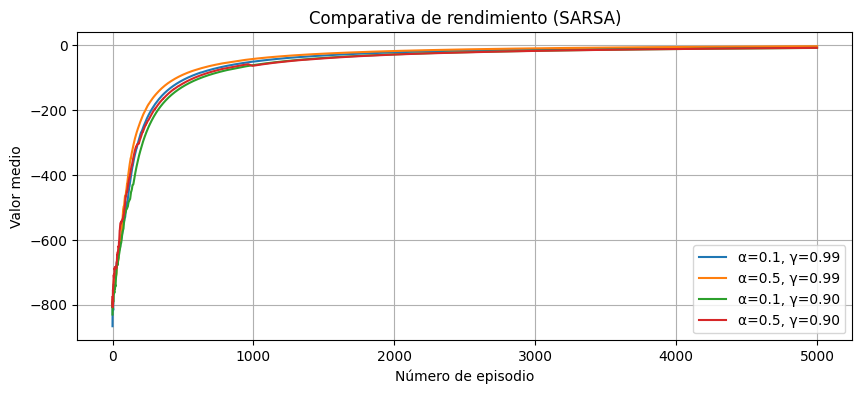

In [16]:
draw_multiple_learning_curves(dict_stats)

En la gráfica se observa que todas las configuraciones convergen hacia valores próximos a 0 en torno al episodio 2000, lo que indica que todas alcanzan políticas cercanas a la óptima.

En este sentido, destaca la rapidez de la convergencia, mucho más rápida que en el caso de Monte Carlo, y lo similares que son las curvas para todas las configuraciones.

Vamos a mostrar una visión ampliada de los primeros episodios para poder analizarla mejor:


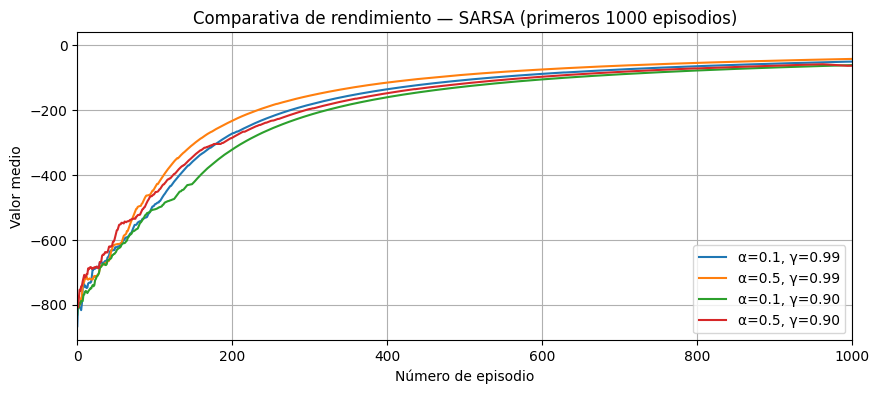

In [17]:
draw_multiple_learning_curves(dict_stats, limit=1000)

Podemos ver que el factor más influyente parece ser la tasa de aprendizaje $\alpha$. Las configuraciones con $\alpha = 0.5$ (naranja y roja) ascienden de forma ligeramente más rápida que las de $\alpha = 0.1$ (azul y verde), especialmente entre los episodios 100 y 500. Esto se explica por la naturaleza determinista de Taxi-v3: al no haber grandes recompensas entre las transiciones, actualizar los valores Q de forma agresiva resulta fiable y acelera el aprendizaje.

El factor de descuento $\gamma$ tiene un efecto más sutil pero visible. Para un mismo $\alpha$, las configuraciones con $\gamma = 0.99$ alcanzan valores ligeramente superiores que las de $\gamma = 0.90$. Esto es coherente con la estructura de recompensas del entorno, donde la única señal positiva (+20) se obtiene al final de la tarea y un $\gamma$ alto permite propagarla mejor hacia los estados previos.

La mejor combinación global es $\alpha = 0.5$, $\gamma = 0.99$, que muestra la convergencia más rápida y el rendimiento final más alto.

A continuación estudiamos las **longitudes de episodio**:

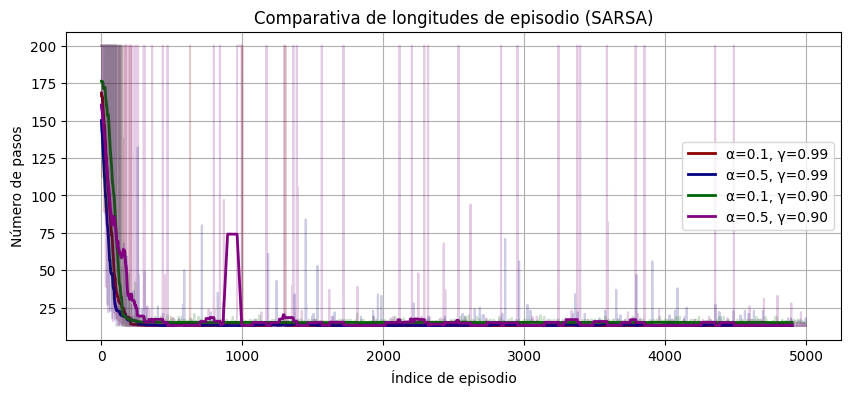

In [18]:
draw_episode_length_comparison(dict_len)

La gráfica de longitud de episodios confirma lo observado en las curvas de rendimiento. Todas las configuraciones parten de episodios cercanos al límite máximo de 200 pasos y convergen rápidamente hacia valores estables en torno a 15 pasos, lo que indica que el agente aprende rutas eficientes y probablemente óptimas.

Ampliamos la gráfica a los primeros episodios para poder estudiarla mejor:

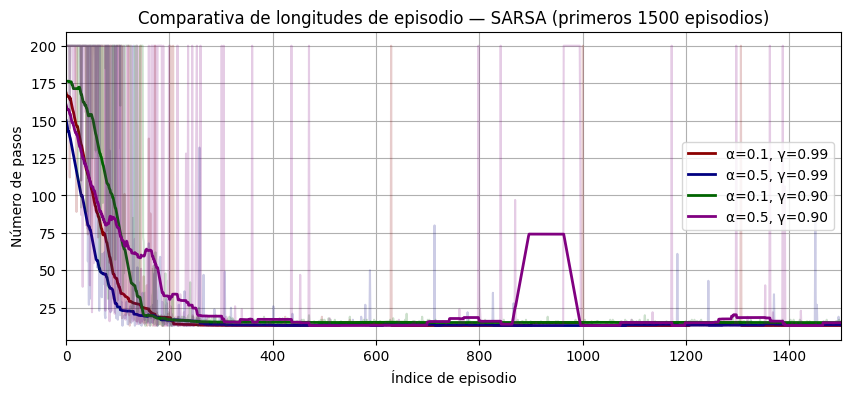

In [19]:
draw_episode_length_comparison(dict_len, limit=1500)

Como fenómeno destacable, también observamos picos esporádicos de longitud a lo largo del entrenamiento, que corresponden a episodios donde la exploración residual lleva al agente a tomar acciones subóptimas puntuales; estos picos son más frecuentes en la configuración $\alpha = 0.5$, $\gamma = 0.90$, lo que sugiere que un horizonte de recompensas más corto genera una política ligeramente menos robusta frente a perturbaciones en la exploración.

#### Visualización de la política aprendida
Ahora vamos a visualizar la política aprendida, usando las funciones auxiliares que muestran visualmente la política.

Para poder visualizar el comportamiento aprendido por el agente, se fija la posición del pasajero y el destino, representando únicamente la política asociada a esa sección concreta del espacio de estados. De esta forma, se construye un mapa 5×5 que muestra la acción greedy seleccionada por el agente para cada posición del taxi bajo esas condiciones fijas.

Es importante destacar que esta representación no muestra la política global del agente, sino una proyección bidimensional condicionada a un estado específico del pasajero y del destino.

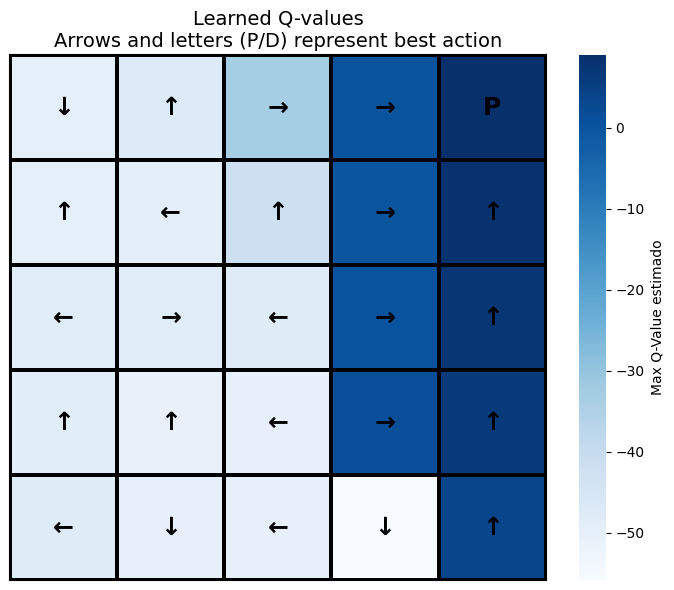

In [20]:
# Mostramos el mapa de la política aprendida para el mejor agente (α=0.5, γ=0.99)
plot_taxi_q_values_map(agent_a05_g099.get_q_values(), env)

En el diagrama se aprecia que el agente con la mejor configuración ($\alpha = 0.5$, $\gamma = 0.99$) muestra valores Q altos y coherentes, con flechas de dirección que reflejan claramente el intento de desplazarse hacia la posición del pasajero, lo que resulta correcto y demuestra que ha aprendido una buena política.

Finalmente, mostramos en un gif la ejecución del agente, para ilustrar el resultado logrado mediante el entrenamiento:

Episodio de prueba finalizado.
Recompensa total: 8.0
Pasos realizados: 13
Archivo guardado en: SARSA_Taxi_Optimal.gif



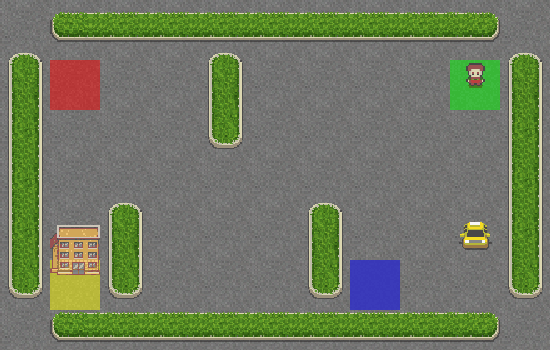

In [21]:
reward, len_episode, frames = capture_optimal_behavior(agent_a05_g099)

print(f"Episodio de prueba finalizado.")
print(f"Recompensa total: {reward}")
print(f"Pasos realizados: {len_episode}")

# Crear y mostrar el GIF
path_gif = "SARSA_Taxi_Optimal.gif"
create_gif_from_frames(frames, path_gif)
print("Archivo guardado en:", path_gif)
show_gif_in_notebook(path_gif)

## Conclusiones

El experimento planteado nos ha permitido estudiar de forma sistemática la sensibilidad de SARSA respecto a sus dos hiperparámetros fundamentales ($\alpha$ y $\gamma$) en un entorno determinista con recompensas dispersas.

De los resultados hemos extraído que la tasa de aprendizaje parece ser el factor más determinante en la velocidad de convergencia: $\alpha = 0.5$ converge en un menor número de iteraciones y obtiene los mejores valores de recompensa, pero con una diferencia no muy grande.

El factor de descuento, por su parte, parece influir más en la calidad final de la política: $\gamma = 0.99$ permite propagar eficazmente la recompensa del final (+20) hacia todos los estados previos, produciendo rutas más óptimas y una menor variabilidad. La mejor combinación global ($\alpha = 0.5$, $\gamma = 0.99$) parece indicar que, en entornos de estas características, la estrategia correcta es un aprendizaje rápido y una planificación a largo plazo.

Finalmente, la comparación con los resultados de Monte Carlo resulta especialmente interesante, ya que Monte Carlo necesitaba miles de episodios para mostrar mejoras graduales y en muchas configuraciones no alcanzaba convergencia clara, mientras que SARSA converge de forma consistente en las primeras 500 iteraciones gracias a su actualización paso a paso. Esto nos ha permitido comprobar de primera mano la ventaja práctica de este enfoque de diferencias temporales.